# Modeling the data

In [2]:
import mlflow
import os


mlflow.set_tracking_uri("../mlruns") 

In [3]:
#importing the libraries
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

print ('libraries imported')

libraries imported


## I-Data preprocessing

In [4]:
#import the data set
df=pd.read_csv('../data/processed_data.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### 1-Preprocessing the data

In [5]:
#Spliting the data in train, test sets
X=df.drop('Class', axis=1)
y=df['Class']
X_train, X_test, y_train, y_test=train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)



In [6]:
# Scaling numerical features and using OneHotEncoder for categoricals
num_cols=X_train.select_dtypes(include='number').columns.tolist()
cat_cols=X_train.select_dtypes(include='object').columns.tolist()

#Preprocessors
scaler=RobustScaler()
encoder=OneHotEncoder(handle_unknown="ignore")

# Preprocessiong data
preprocessor=ColumnTransformer(transformers=[
    ('num', scaler, num_cols),
    ('cat', encoder, cat_cols)])
#Apply the preprocessors
X_train_processed=preprocessor.fit_tranform(X_train)
X_test_processed=preprocessor.tranform(X_test)

# 4. Apply smoote on preprocessed training data
print("Distribution before SMOTE :", y_train.value_counts())
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_processed, y_train)
print("Distribution after SMOTE :", y_train.value_counts())


### 2-Training models and following with mlflow 

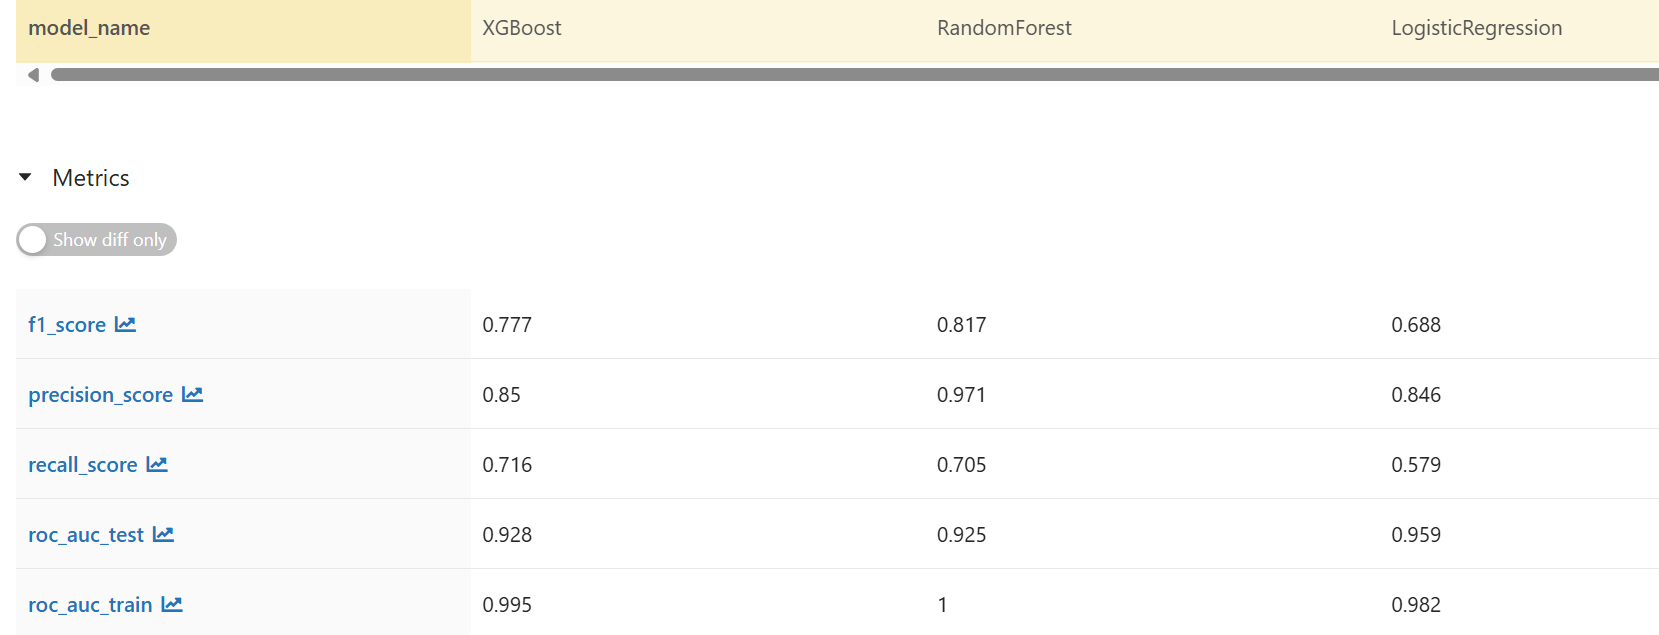

In [2]:
from IPython.display import Image, display


display(Image(filename="model_comparison.png"))
